# Spec-S5 Mock Observations Demo

This notebook demonstrates the full mock-observation pipeline:

1. Simulate a halo stellar population in Galactocentric coordinates
2. `galactocentric_to_observed` — convert to on-sky observables (RA, Dec, distance, vrad, pm, z)
3. `observe_with_spec5` — apply Spec-S5 measurement errors to produce mock observations

Stars are old, metal-poor RGB giants drawn from a smooth spherical halo at 20–100 kpc.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from spec5.instrument.mock_observations import galactocentric_to_observed, observe_with_spec5

## 1. Simulate a halo stellar population

We draw 500 RGB giants uniformly in a spherical shell at Galactocentric radii 20–100 kpc,
with random velocities consistent with a hot stellar halo (dispersion ~100 km/s, mean rotation ~50 km/s).
Luminosities are log-normally distributed around 50 L_sun, typical for lower RGB stars.

In [2]:
rng = np.random.default_rng(42)
n = 500

# Positions: uniform in spherical shell, 20–100 kpc
r     = rng.uniform(20, 100, n)
theta = np.arccos(rng.uniform(-1, 1, n))   # polar angle
phi   = rng.uniform(0, 2 * np.pi, n)       # azimuthal angle
x =  r * np.sin(theta) * np.cos(phi)
y =  r * np.sin(theta) * np.sin(phi)
z =  r * np.cos(theta)

# Velocities: isotropic dispersion + mild prograde rotation
vx = rng.normal(  0, 100, n)
vy = rng.normal( 50, 100, n)
vz = rng.normal(  0, 100, n)

# Luminosities: log-normal around 50 L_sun
lum = np.exp(rng.normal(np.log(50), 0.5, n))

dtype = [('x','f8'), ('y','f8'), ('z','f8'),
         ('vx','f8'), ('vy','f8'), ('vz','f8'),
         ('luminosity','f8')]
stars = np.array(list(zip(x, y, z, vx, vy, vz, lum)), dtype=dtype)

print(f'Simulated {n} RGB giants')
print(f'Galactocentric radius: {r.min():.1f} – {r.max():.1f} kpc')
print(f'Luminosity: {lum.min():.1f} – {lum.max():.1f} L_sun')

Simulated 500 RGB giants
Galactocentric radius: 20.4 – 99.9 kpc
Luminosity: 12.6 – 234.2 L_sun


## 2. Convert to on-sky observables

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    obs = galactocentric_to_observed(stars, star_type='giant')

print(f'Heliocentric distance: {obs["distance"].min():.1f} – {obs["distance"].max():.1f} kpc')
print(f'LSST z magnitude:      {obs["lsst_z"].min():.2f} – {obs["lsst_z"].max():.2f}')
print(f'Radial velocity:       {obs["vrad"].min():.1f} – {obs["vrad"].max():.1f} km/s')

Heliocentric distance: 13.1 – 106.6 kpc
LSST z magnitude:      14.37 – 21.02
Radial velocity:       -436.2 – 492.9 km/s


## 3. Apply Spec-S5 measurement errors

In [4]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    mock = observe_with_spec5(obs, star_type='giant', pm_model='gaia_dr5', seed=42)

print(f'vrad_err:      {mock["vrad_err"].min():.2f} – {mock["vrad_err"].max():.2f} km/s')
print(f'pm_err:        {np.nanmin(mock["pm_err"]):.4f} – {np.nanmax(mock["pm_err"]):.4f} mas/yr')
print(f'dist_err_frac: {mock["dist_err_frac"].min():.3f} – {mock["dist_err_frac"].max():.3f}')
print(f'NaN pm_err (G > 20.7): {np.sum(np.isnan(mock["pm_err"]))}')

vrad_err:      0.60 – 2.75 km/s
pm_err:        0.0038 – 0.1575 mas/yr
dist_err_frac: 0.056 – 0.557
NaN pm_err (G > 20.7): 8


## Sky distribution

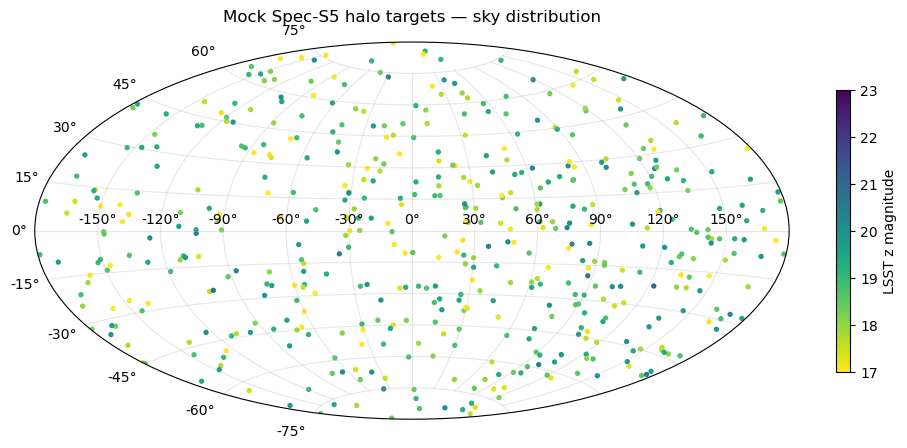

In [5]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': 'aitoff'})

ra_rad  = np.deg2rad(obs['ra'] - 180)   # centre on RA=180
dec_rad = np.deg2rad(obs['dec'])

sc = ax.scatter(ra_rad, dec_rad, c=obs['lsst_z'], s=8,
                cmap='viridis_r', vmin=17, vmax=23)
plt.colorbar(sc, ax=ax, label='LSST z magnitude', shrink=0.6)
ax.set_title('Mock Spec-S5 halo targets — sky distribution', pad=15)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Measurement errors vs LSST z magnitude

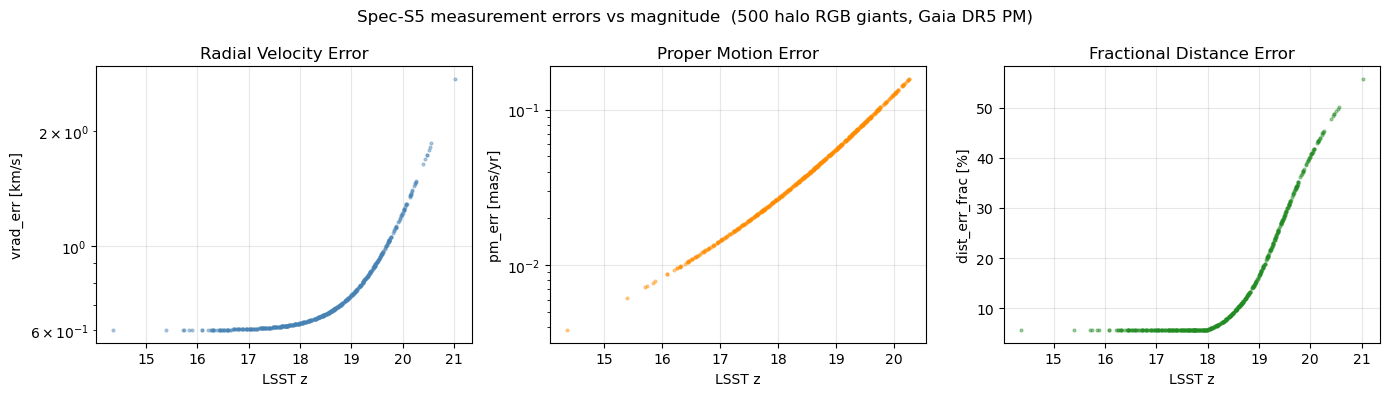

In [6]:
z = obs['lsst_z']

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].semilogy(z, mock['vrad_err'], '.', alpha=0.4, color='steelblue', ms=4)
axs[0].set(xlabel='LSST z', ylabel='vrad_err [km/s]', title='Radial Velocity Error')

axs[1].semilogy(z, mock['pm_err'], '.', alpha=0.4, color='darkorange', ms=4)
axs[1].set(xlabel='LSST z', ylabel='pm_err [mas/yr]', title='Proper Motion Error')

axs[2].plot(z, mock['dist_err_frac'] * 100, '.', alpha=0.4, color='forestgreen', ms=4)
axs[2].set(xlabel='LSST z', ylabel='dist_err_frac [%]', title='Fractional Distance Error')

for ax in axs:
    ax.grid(alpha=0.3)

plt.suptitle('Spec-S5 measurement errors vs magnitude  (500 halo RGB giants, Gaia DR5 PM)')
plt.tight_layout()
plt.show()

## True vs observed: radial velocity

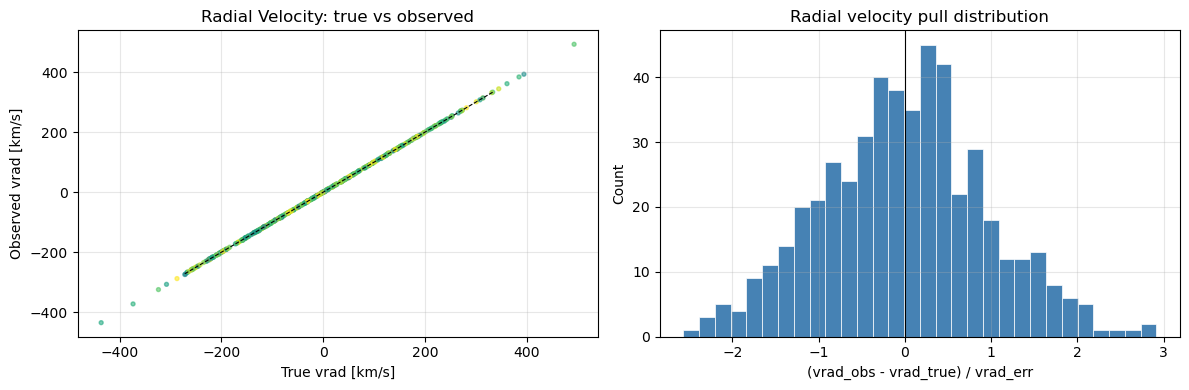

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].scatter(obs['vrad'], mock['vrad_obs'], c=z, s=8, cmap='viridis_r',
               vmin=17, vmax=23, alpha=0.6)
lim = np.percentile(obs['vrad'], [1, 99])
axs[0].plot(lim, lim, 'k--', lw=0.8)
axs[0].set(xlabel='True vrad [km/s]', ylabel='Observed vrad [km/s]',
           title='Radial Velocity: true vs observed')
axs[0].grid(alpha=0.3)

residuals = mock['vrad_obs'] - obs['vrad']
axs[1].hist(residuals / mock['vrad_err'], bins=30, color='steelblue',
            edgecolor='white', linewidth=0.5)
axs[1].axvline(0, color='k', lw=0.8)
axs[1].set(xlabel='(vrad_obs - vrad_true) / vrad_err', ylabel='Count',
           title='Radial velocity pull distribution')
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## True vs observed: proper motion

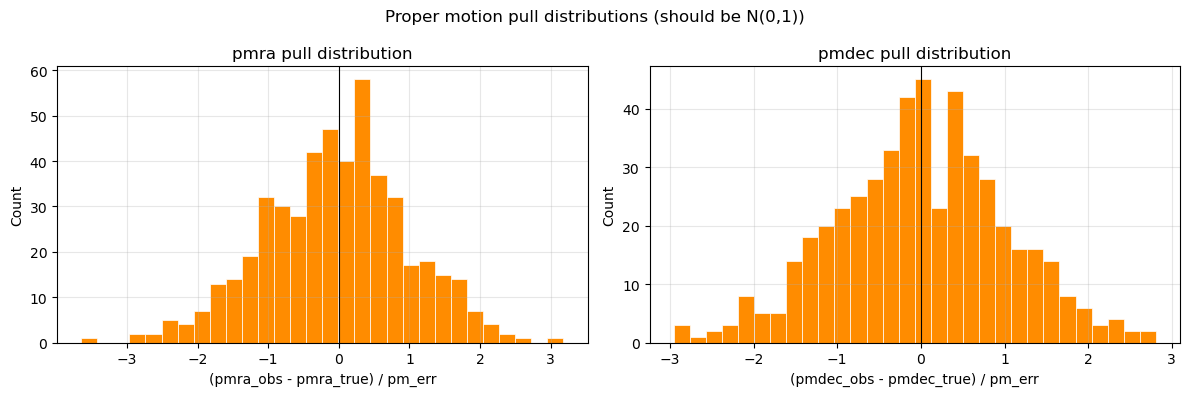

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

for ax, true, obs_col, label in [
    (axs[0], obs['pmra'],  mock['pmra_obs'],  'pmra'),
    (axs[1], obs['pmdec'], mock['pmdec_obs'], 'pmdec'),
]:
    residuals = (obs_col - true) / mock['pm_err']
    finite = np.isfinite(residuals)
    ax.hist(residuals[finite], bins=30, color='darkorange',
            edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='k', lw=0.8)
    ax.set(xlabel=f'({label}_obs - {label}_true) / pm_err',
           ylabel='Count', title=f'{label} pull distribution')
    ax.grid(alpha=0.3)

plt.suptitle('Proper motion pull distributions (should be N(0,1))')
plt.tight_layout()
plt.show()

## True vs observed: heliocentric distance

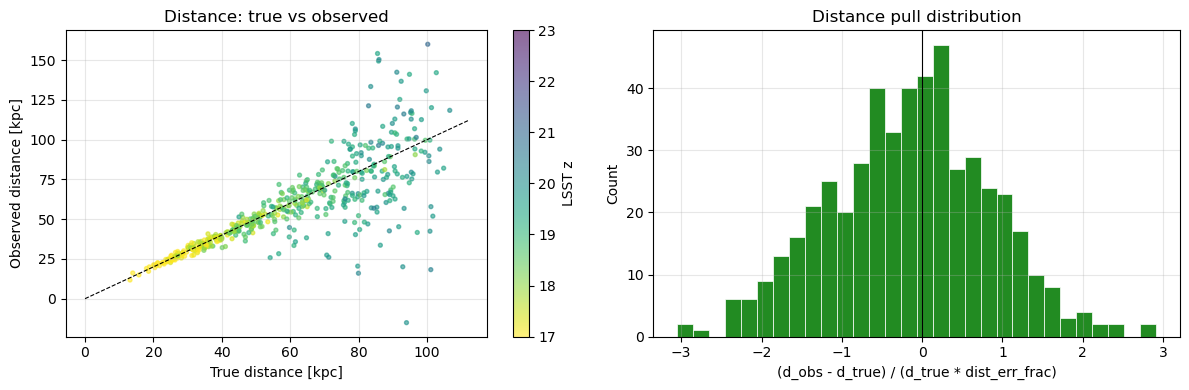

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

sc = axs[0].scatter(obs['distance'], mock['distance_obs'], c=z, s=8,
                    cmap='viridis_r', vmin=17, vmax=23, alpha=0.6)
plt.colorbar(sc, ax=axs[0], label='LSST z')
lim = [0, obs['distance'].max() * 1.05]
axs[0].plot(lim, lim, 'k--', lw=0.8)
axs[0].set(xlabel='True distance [kpc]', ylabel='Observed distance [kpc]',
           title='Distance: true vs observed')
axs[0].grid(alpha=0.3)

pull = (mock['distance_obs'] - obs['distance']) / (obs['distance'] * mock['dist_err_frac'])
axs[1].hist(pull, bins=30, color='forestgreen', edgecolor='white', linewidth=0.5)
axs[1].axvline(0, color='k', lw=0.8)
axs[1].set(xlabel='(d_obs - d_true) / (d_true * dist_err_frac)',
           ylabel='Count', title='Distance pull distribution')
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()